## Marketing Strategy Analysis

**Project Goal:** 
How can we improve conversion rate of our leads?

**About The Dataset:**
Olist is the largest department store in Brazilian marketplaces. which allows small businesses to sell products via Olist stores. 

Marketing leads table provides info about the total leads and sources, and time of contact.

Closed deals table provides the converted leads, business segment, lead source and revenue data.

Joining these 2 datasets allow me to analyze the performance of the different marketing sources, business segment performance and the convertion rate for each lead source. 



**Key questions to answer:**
* KPI's for Power BI Dashboard

1. Count of total leads

2. Convesion Rate & Count 

* Marketing Effectiveness

3. Leads by source.

4. Converted leads by source.

5. Conversion rate by source.

* Time trend analysis

6. Monthly leads and converted leads by source.

7. best month for a marketing campaign?

* Business Segment Performance

8. Best segment in Converted leads

9. Best Segments to target?

* Seller Profile Analysis

10. What types of sellers does the company end up acquiring?

**Excecutive Summary at the end of the Notebook**

# Table of Contents

1. Importing Libraries and Data 

2. Data Inspection and Cleaning

3. Funnel Performance

4. Marketing Effectiveness

5. Time Trend Analysis

6. Business Segment Analysis

7. Excecutive Summary

## Step 1: Imorting Libraries and Data

Importing libraries 

In [4]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns
import os 

Loading the dataset and checking my data 

In [5]:
# changing the current working directory to this :/Users/user/Desktop/Data Analytics/John Bryce Data Analysis/Python/Marketing_Analysis_Idan_JB/Raw_Data


# Change to an absolute path
os.chdir('/Users/user/Desktop/Data Analytics/John Bryce Data Analysis/Python/Marketing_Analysis_Idan_JB/Raw_Data')
# Check the current working directory
print(os.getcwd())


/Users/user/Desktop/Data Analytics/John Bryce Data Analysis/Python/Marketing_Analysis_Idan_JB/Raw_Data


In [6]:
# This data set tell me: 
# The lead source 
# Contact date with each lead
# How many leads enter the funnel by dividing the total number of leads by the total number of converted leads in the 2nd dataset.

lead_data= pd.read_csv('olist_marketing_qualified_leads_dataset.csv')
lead_data.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [7]:
# This data set tell me:
# the number of converted leads 
# date of conversion to compare with the first_contact_date in the first dataset
# sales rep performance by convertion rate.
# business segments - which allows me to understand in which segments to invest. 

closed_deals = pd.read_csv('olist_closed_deals_dataset.csv')
closed_deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


In [8]:
# Disabling scientific notation globally in Pandas
pd.set_option('display.float_format', '{:,.2f}'.format)

## Step 2: Data Inspecting & Cleaning

Converting data types

In [9]:
# checking the data types and missing values in the first dataset
lead_data.info()
# 'first_contact_date ' column isnt a datetime type, and there are 60 missing values in the origin column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   mql_id              8000 non-null   object
 1   first_contact_date  8000 non-null   object
 2   landing_page_id     8000 non-null   object
 3   origin              7940 non-null   object
dtypes: object(4)
memory usage: 250.1+ KB


In [10]:
# converting 'first_contact_date ' to datetime type
lead_data['first_contact_date'] = pd.to_datetime(lead_data['first_contact_date'], errors='coerce')

In [11]:
# checking the data types and missing values in the 2nd dataset
closed_deals.info()
# 'won_date' column isnt a datetime type, and there are 4 columns with a lot of missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mql_id                         842 non-null    object 
 1   seller_id                      842 non-null    object 
 2   sdr_id                         842 non-null    object 
 3   sr_id                          842 non-null    object 
 4   won_date                       842 non-null    object 
 5   business_segment               841 non-null    object 
 6   lead_type                      836 non-null    object 
 7   lead_behaviour_profile         665 non-null    object 
 8   has_company                    63 non-null     object 
 9   has_gtin                       64 non-null     object 
 10  average_stock                  66 non-null     object 
 11  business_type                  832 non-null    object 
 12  declared_product_catalog_size  69 non-null     flo

In [12]:
# converting the 'won_date' column to datetime type
closed_deals['won_date'] = pd.to_datetime(closed_deals['won_date'], errors='coerce')

In [13]:
# Before merging, converting both 'mql_id' columns to str data type, to avoid any issues during the merge process.
lead_data["mql_id"] = lead_data["mql_id"].astype(str)
closed_deals["mql_id"] = closed_deals["mql_id"].astype(str)

Dropping unnecessary columns

In [14]:
# Dropping columns with a lot of missing values
closed_deals.drop(columns=['has_company', 'has_gtin','lead_behaviour_profile', 'average_stock', 'declared_product_catalog_size', 'declared_monthly_revenue'], inplace=True)

checking for duplicates in both datasets

In [15]:
lead_data.duplicated().sum()

0

In [16]:
closed_deals.duplicated().sum()

0

In [17]:
# Merge the two datasets on 'mql_id' to combine lead information with closed deal information
# This will allow me to analyse the entire funnel from lead generation to deal closure
# And understand the conversion rates at each stage of the funnel 
raw_data = pd.merge(lead_data, closed_deals, on='mql_id', how='left')
raw_data.head()

,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,business_type
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,reseller


In [18]:
#checking the data shape and statistical summary to understand the data better and identify any potential issues or insights.
print('Data shape:', raw_data.shape)
raw_data.describe(include='all') #include='all' to get the summary of both numerical and categorical columns

Data shape: (8000, 11)


,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,business_type
count,8000,8000,8000,7940,842,842,842,842,841,836,832
unique,8000,NaN,495,10,842,32,22,NaN,33,8,3
top,dac32acd4db4c29c230538b72f8dd87d,NaN,b76ef37428e6799c421989521c0e5077,organic_search,2c43fb513632d29b3b58df74816f1b06,4b339f9567d060bcea4f5136b9f5949e,4ef15afb4b2723d8f3d81e51ec7afefe,NaN,home_decor,online_medium,reseller
freq,1,NaN,912,2296,1,140,133,NaN,105,332,587
mean,NaN,2018-02-05 14:19:51.600000256,NaN,NaN,NaN,NaN,NaN,2018-04-23 06:04:00.891923968,NaN,NaN,NaN
min,NaN,2017-06-14 00:00:00,NaN,NaN,NaN,NaN,NaN,2017-12-05 02:00:00,NaN,NaN,NaN
25%,NaN,2017-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,2018-03-07 12:48:36.249999872,NaN,NaN,NaN
50%,NaN,2018-02-25 00:00:00,NaN,NaN,NaN,NaN,NaN,2018-04-13 21:22:15,NaN,NaN,NaN
75%,NaN,2018-04-15 06:00:00,NaN,NaN,NaN,NaN,NaN,2018-05-21 17:38:27.500000,NaN,NaN,NaN
max,NaN,2018-05-31 00:00:00,NaN,NaN,NaN,NaN,NaN,2018-11-14 18:04:19,NaN,NaN,NaN


In [19]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   mql_id              8000 non-null   object        
 1   first_contact_date  8000 non-null   datetime64[ns]
 2   landing_page_id     8000 non-null   object        
 3   origin              7940 non-null   object        
 4   seller_id           842 non-null    object        
 5   sdr_id              842 non-null    object        
 6   sr_id               842 non-null    object        
 7   won_date            842 non-null    datetime64[ns]
 8   business_segment    841 non-null    object        
 9   lead_type           836 non-null    object        
 10  business_type       832 non-null    object        
dtypes: datetime64[ns](2), object(9)
memory usage: 687.6+ KB


In [20]:
# filling in the missing values in origin as 'unknown' and not dropping this information
# because an unknown leads source is still a lead source and it can give us insights 
raw_data['origin'].fillna('unknown', inplace=True)

/var/folders/31/m59dvv9907z8t7s5g400ls440000gn/T/ipykernel_9718/158859200.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data['origin'].fillna('unknown', inplace=True)


In [21]:
# converting columns names to more readable names
raw_data.rename(columns={
    'mql_id': 'lead_id', 
    'origin': 'lead_source',
    'sdr_id': 'sales_dep_id',
    'sr_id': 'sales_rep_id',
    'won_date': 'deal_closed_date'}, inplace=True)

raw_data.head()

,lead_id,first_contact_date,landing_page_id,lead_source,seller_id,sales_dep_id,sales_rep_id,deal_closed_date,business_segment,lead_type,business_type
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,reseller


In [22]:
# Creating a new column 'converted' to indicate whether a lead converted or not, based on the presence of a seller_id in the closed_deals dataset.
raw_data["converted"] = raw_data["seller_id"].notna()

In [23]:
# Creating a new column 'lead_month' to extract the month and year from the 'first_contact_date' column,
# To analyze the funnel performance over time.
raw_data["lead_month"] = raw_data["first_contact_date"].dt.to_period("M")
raw_data.head()
#Leads & convertions per month
#Conversion rate trend over time

,lead_id,first_contact_date,landing_page_id,lead_source,seller_id,sales_dep_id,sales_rep_id,deal_closed_date,business_segment,lead_type,business_type,converted,lead_month
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2018-02
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2017-10
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2018-03
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2018-01
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,reseller,True,2018-02


In [24]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lead_id             8000 non-null   object        
 1   first_contact_date  8000 non-null   datetime64[ns]
 2   landing_page_id     8000 non-null   object        
 3   lead_source         8000 non-null   object        
 4   seller_id           842 non-null    object        
 5   sales_dep_id        842 non-null    object        
 6   sales_rep_id        842 non-null    object        
 7   deal_closed_date    842 non-null    datetime64[ns]
 8   business_segment    841 non-null    object        
 9   lead_type           836 non-null    object        
 10  business_type       832 non-null    object        
 11  converted           8000 non-null   bool          
 12  lead_month          8000 non-null   period[M]     
dtypes: bool(1), datetime64[ns](2), object(9), period

In [25]:
# Creating a copy of the raw_data dataframe to work on the funnel analysis.
# Keeping the original cleaned data intact for any future reference or analysis.
df = raw_data.copy()
df.head()

,lead_id,first_contact_date,landing_page_id,lead_source,seller_id,sales_dep_id,sales_rep_id,deal_closed_date,business_segment,lead_type,business_type,converted,lead_month
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2018-02
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2017-10
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2018-03
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaT,NaN,NaN,NaN,False,2018-01
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,reseller,True,2018-02


 ## Step 3: Funnel Performance
Calculating the KPI's 

In [26]:
# Total leads
total_leads = df['lead_id'].nunique()

# Total sellers (converted leads)
total_sellers = df['seller_id'].nunique()

# Conversion rate
conversion_rate_pct = round((total_sellers / total_leads)*100, 2)

# Leads needed per seller
leads_per_seller = round(total_leads / total_sellers, 2)

print("Total Leads:", total_leads)
print("Total Sellers:", total_sellers)
print("Conversion Rate:", str(conversion_rate_pct) + "%")
print("Leads per Seller:", leads_per_seller)

Total Leads: 8000
Total Sellers: 842
Conversion Rate: 10.53%
Leads per Seller: 9.5


In [27]:
#Creating a df for visuals, grouping by lead source to find the total leads and conversions for each source.
df_plot = (df.groupby("lead_source")
           .agg(leads=("lead_id", "count"), conversions=("converted", "sum")))

#adding conversion rate column 
df_plot["conversion_rate"] = (df_plot["conversions"] / df_plot["leads"] * 100)

df_plot = df_plot.sort_values("leads", ascending=False)

df_plot["conversion_rate"] = df_plot["conversion_rate"].round(2)

df_plot

,leads,conversions,conversion_rate
lead_source,,,
organic_search,2296,271,11.80
paid_search,1586,195,12.30
social,1350,75,5.56
unknown,1159,193,16.65
direct_traffic,499,56,11.22
email,493,15,3.04
referral,284,24,8.45
other,150,4,2.67
display,118,6,5.08


# Line plot & Bar chart:
both plots share the same x axis, with each having a unique y-axis

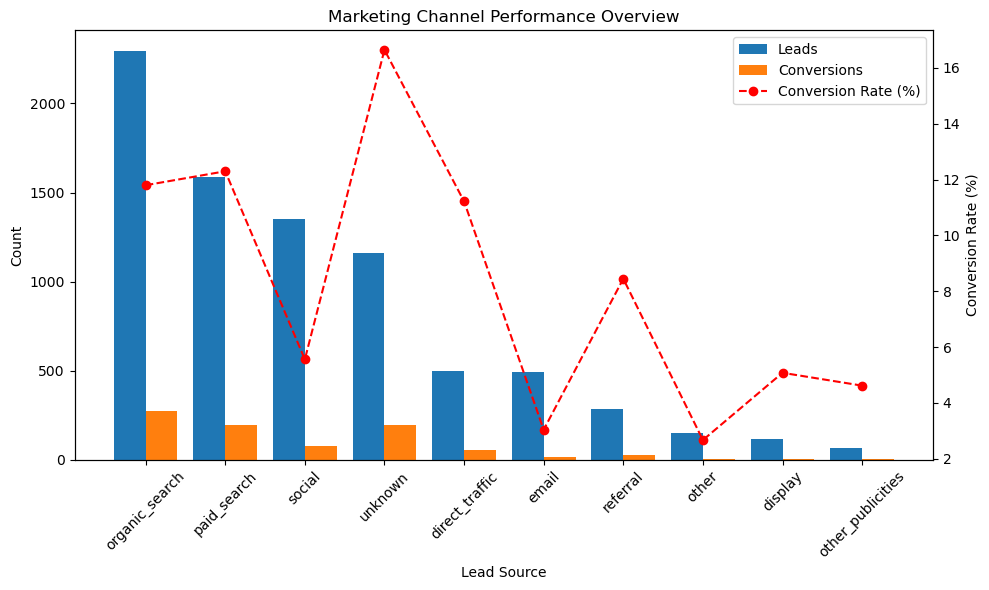

In [28]:
df_plot = df_plot.sort_values("leads", ascending=False)

x = np.arange(len(df_plot))
width = 0.4

fig, ax1 = plt.subplots(figsize=(10,6))

# Bars (counts)
ax1.bar(x - width/2, df_plot["leads"], width, label="Leads")
ax1.bar(x + width/2, df_plot["conversions"], width, label="Conversions")

ax1.set_xlabel("Lead Source")
ax1.set_ylabel("Count")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot.index, rotation=45)

# Line (conversion rate)
ax2 = ax1.twinx()
ax2.plot(x, df_plot["conversion_rate"], marker='o', linestyle='--', label="Conversion Rate (%)", color='red')

ax2.set_ylabel("Conversion Rate (%)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("Marketing Channel Performance Overview")
plt.tight_layout()
plt.show()

# Marketing Channel Performance Insights 
1. **Organic search & Paid search** generate the majority of leads with similar conversion rates, suggesting an opportunity to optimize Paid Search spending and strengthen Organic growth.

2. The **Unknown** channel shows the highest conversion rate, likely indicating attribution gaps that should be investigated.

3. **Social** generates strong awareness (high volume) but weaker conversion, meaning investment decisions should depend on cost-per-customer data.
(I would calculate "Cost Per Customer" if there were costs for each of the marketing channel in this dataset).


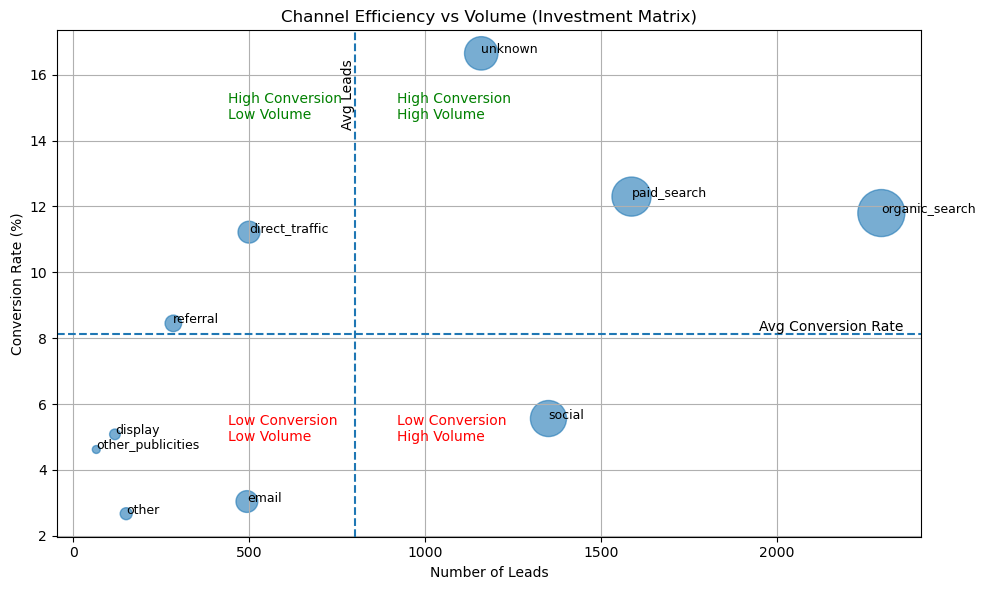

In [29]:
plt.figure(figsize=(10,6))

# Bubble scatter
plt.scatter(
    df_plot["leads"],                 
    df_plot["conversion_rate"],       
    s=df_plot["leads"] * 0.5,         
    alpha=0.6
)

# Labels for each point
for i, txt in enumerate(df_plot.index):
    plt.text(
        df_plot["leads"].iloc[i],
        df_plot["conversion_rate"].iloc[i],
        txt,
        fontsize=9
    )

# Average lines (quadrants)
avg_leads = df_plot["leads"].mean()
avg_conv = df_plot["conversion_rate"].mean()

plt.axvline(avg_leads, linestyle='--')
plt.axhline(avg_conv, linestyle='--')

# Annotations for average lines
plt.text(
    avg_leads,
    plt.ylim()[1]*0.95,
    "Avg Leads",
    rotation=90,
    va='top',
    ha='right'
)

plt.text(
    plt.xlim()[1]*0.98,
    avg_conv,
    "Avg Conversion Rate",
    va='bottom',
    ha='right'
)

# Quadrant labels
plt.text(avg_leads*0.55, avg_conv*1.8, "High Conversion\nLow Volume", color = 'green')
plt.text(avg_leads*1.15, avg_conv*1.8, "High Conversion\nHigh Volume", color = 'green')
plt.text(avg_leads*0.55, avg_conv*0.6, "Low Conversion\nLow Volume", color = 'red')
plt.text(avg_leads*1.15, avg_conv*0.6, "Low Conversion\nHigh Volume", color = 'red')

plt.xlabel("Number of Leads")
plt.ylabel("Conversion Rate (%)")
plt.title("Channel Efficiency vs Volume (Investment Matrix)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Channel Efficiency Recommendations 

1. **Scale:** Organic Search, Paid Search, Unknown
2. **Grow:** Direct Traffic, Referral (high intent but low volume)
3. **Optimize/Test:** Social, Email, Display, Other channels

## Time Trend Analysis


In [30]:
# Preparing a monthly data df for plotting the funnel trends over time, 
# by grouping the data by 'lead_month' and calculating the total leads, conversions, and conversion rate for each month.

monthly = (
    df
    .groupby("lead_month")
    .agg(
        leads=("lead_id", "count"),
        conversions=("converted", "sum")
    )
)

monthly["conversion_rate"] = monthly["conversions"] / monthly["leads"] * 100

# Convert Period → datetime for plotting
monthly.index = monthly.index.to_timestamp()

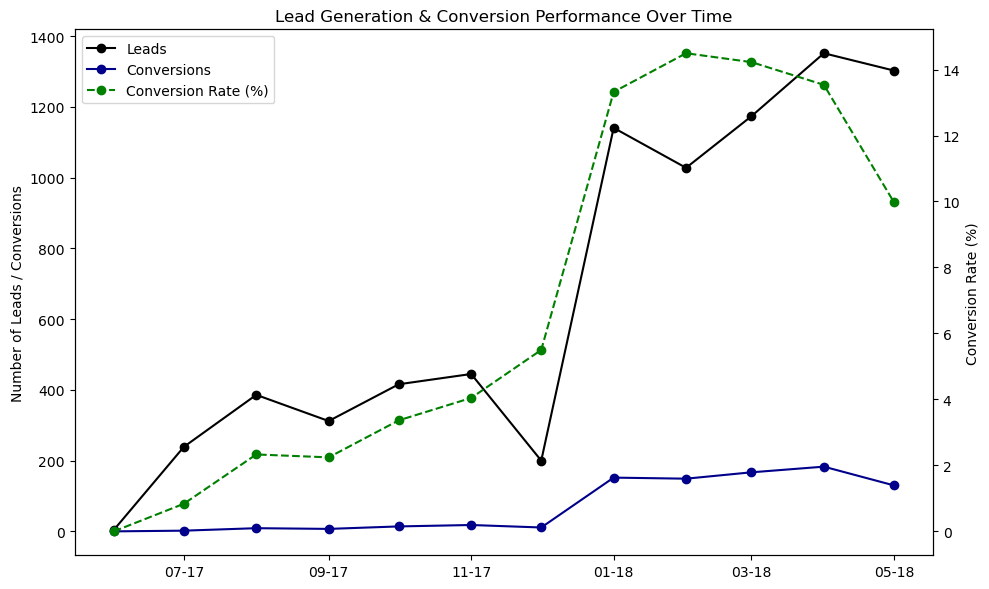

In [31]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Leads & Conversions
ax1.plot(monthly.index, monthly["leads"], marker='o', label="Leads", color='black')
ax1.plot(monthly.index, monthly["conversions"], marker='o', label="Conversions", color='darkblue')
ax1.set_ylabel("Number of Leads / Conversions")

# Conversion rate (secondary axis)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["conversion_rate"], linestyle='--', marker='o', label="Conversion Rate (%)", color='Green')
ax2.set_ylabel("Conversion Rate (%)")

# Date formatting
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
plt.xticks(rotation=45)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Lead Generation & Conversion Performance Over Time")
plt.tight_layout()
plt.show()

# Time Trend Insights
1. January 2018 marks a clear inflection point where leads, conversions, and conversion rate begin a sustained upward trend.

2. Both lead volume and conversion efficiency increased simultaneously, indicating improved traffic quality rather than volume alone.

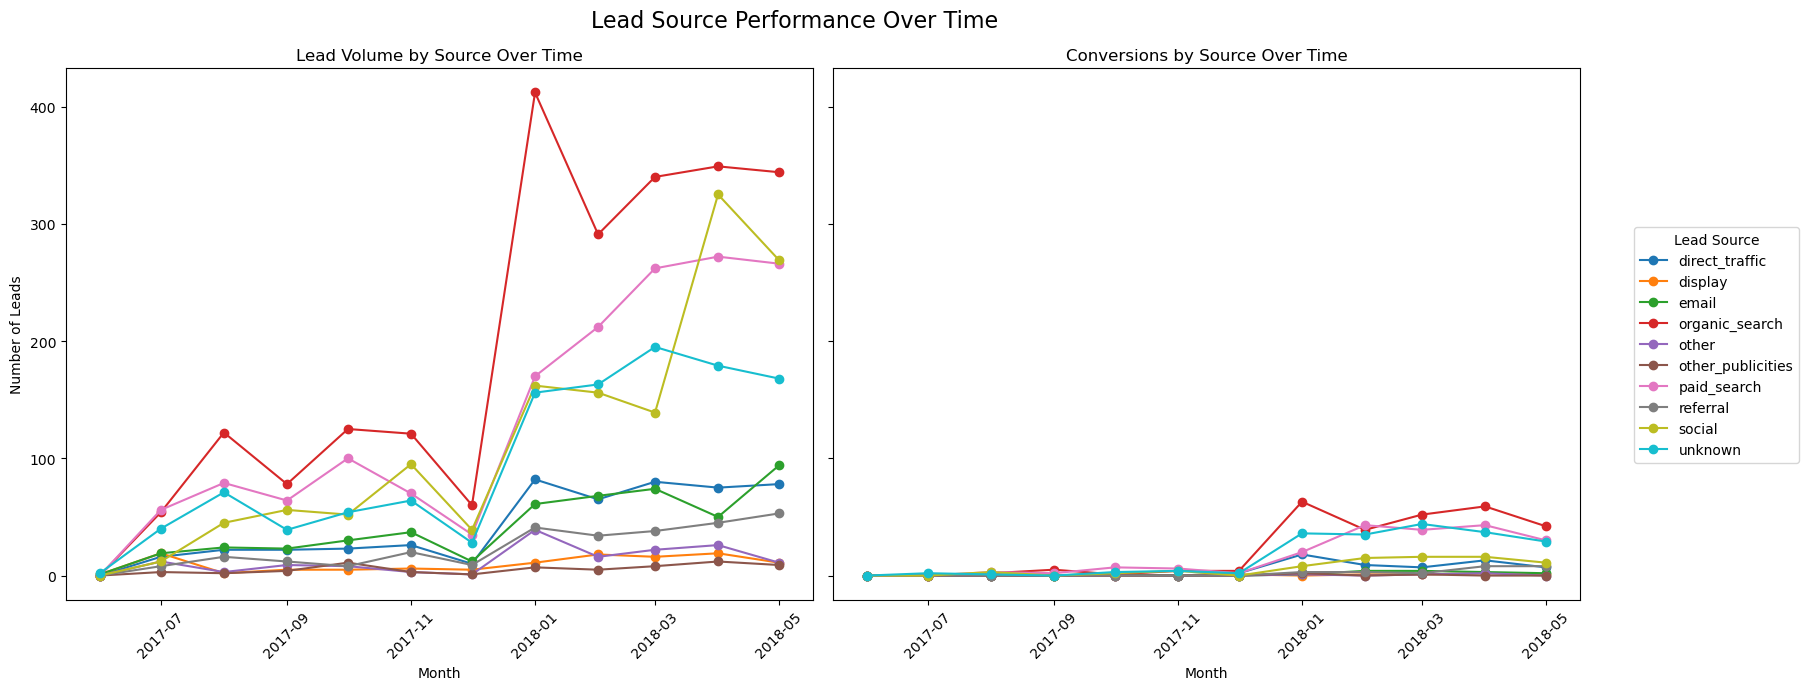

In [32]:
# Prepare pivot tables
pivot_leads = df.pivot_table(
    index='lead_month',
    columns='lead_source',
    values='lead_id',
    aggfunc='count'
).fillna(0)

pivot_conv = df.pivot_table(
    index='lead_month',
    columns='lead_source',
    values='converted',
    aggfunc='sum'
).fillna(0)

# Convert PeriodIndex → datetime
pivot_leads.index = pivot_leads.index.to_timestamp()
pivot_conv.index = pivot_conv.index.to_timestamp()

# Create subplots with shared Y-axis
fig, axes = plt.subplots(1, 2, figsize=(16,7), sharey=True)

# --- Left plot: Leads ---
for column in pivot_leads.columns:
    axes[0].plot(pivot_leads.index, pivot_leads[column], marker='o', label=column)

axes[0].set_title("Lead Volume by Source Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Leads")
axes[0].tick_params(axis='x', rotation=45)

# --- Right plot: Conversions ---
for column in pivot_conv.columns:
    axes[1].plot(pivot_conv.index, pivot_conv[column], marker='o')

axes[1].set_title("Conversions by Source Over Time")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis='x', rotation=45)

# Shared legend for both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Lead Source", bbox_to_anchor=(1.02, 0.5), loc="center left")

# Main figure title
fig.suptitle("Lead Source Performance Over Time", fontsize=16)

plt.tight_layout()
plt.show()

# Lead Source Trends Insights
1. All acquisition channels experienced a sharp increase in lead volume at the start of 2018.
2. **Organic Search** became the dominant channel, jumping from under 100 to over 400 monthly leads.
3. **Paid Search, Social, and Unknown** sources roughly tripled their lead volume, suggesting multi-channel scaling.
4. December shows a consistent dip across channels, likely reflecting seasonal holiday slowdowns.


## Business Segment Analysis

In [33]:
# Segment performance table
segment_perf = (
    df[df["converted"] == True]
    .groupby("business_segment")
    .agg(
        sellers=("seller_id", "count")
    )
    .dropna()
    .sort_values("sellers", ascending=False)
)

segment_perf.head(10)

,sellers
business_segment,
home_decor,105
health_beauty,93
car_accessories,77
household_utilities,71
construction_tools_house_garden,69
audio_video_electronics,64
computers,34
pet,30
food_supplement,28


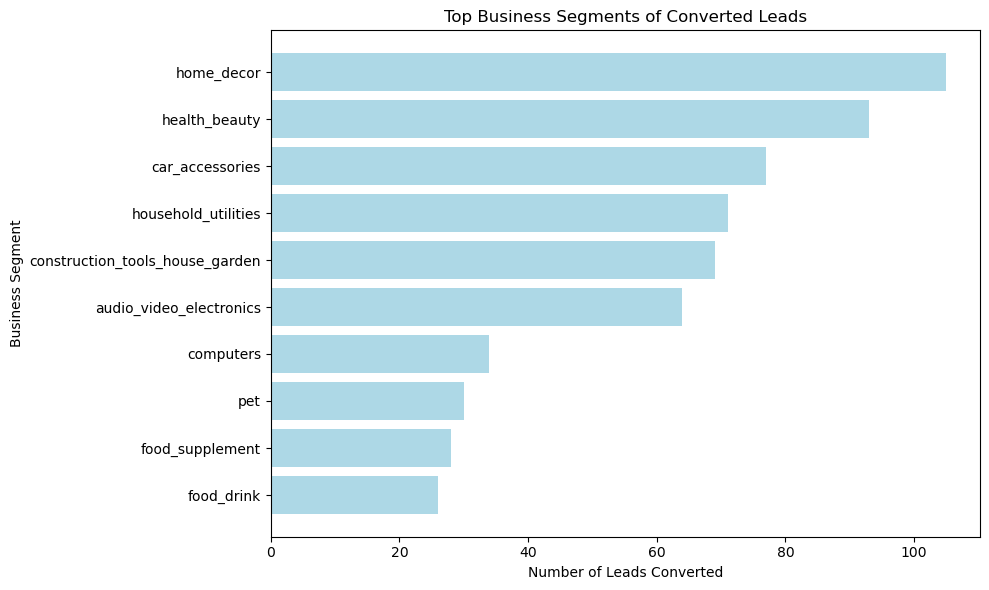

In [34]:
# top 10 segments 
top_seg = segment_perf.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_seg.index, top_seg["sellers"], color = "lightblue")

plt.xlabel("Number of Leads Converted")
plt.ylabel("Business Segment")
plt.title("Top Business Segments of Converted Leads")

plt.gca().invert_yaxis()  # biggest at top
plt.tight_layout()
plt.show()

## Business Segment Insights
1. Business segment data exists only for converted sellers, so conversion rate by segment cannot be calculated.

2. The platform attracts a clear core group of industries, led by **Home Decor, Health & Beauty, Car Accessories, Household Utilities, and Construction Tools.**

3. **Electronics-related segments(Audio/Video Electronics, Computers) form a strong secondary cluster**, indicating traction with higher-value sellers.

4. Smaller segments such as Pet, Food & Drink, and Food Supplements appear as emerging niches with **growth potential.**


## Business Segment Recommendations

1. **Double Down (core segments)**

Focus marketing and onboarding efforts on Home Decor, Beauty, Household, and Tools — these show the highest volume of converted leads

2. **Expand (high-value opportunity)**

Increase targeted acquisition of Electronics and Computer sellers to grow a high-value segment.

3. **Test (emerging niches)**

Run small targeted experiments for Pet, Food, and Supplement sellers to evaluate future growth potential.

# Step 7: Seller Profile Analysis

In [35]:
lead_type_perf = (
    df[df["converted"] == True]
    .groupby("lead_type")
    .agg(sellers=("seller_id","count"))
    .dropna()
    .sort_values("sellers", ascending=False)
)

lead_type_perf

,sellers
lead_type,
online_medium,332
online_big,126
industry,123
offline,104
online_small,77
online_beginner,57
online_top,14
other,3


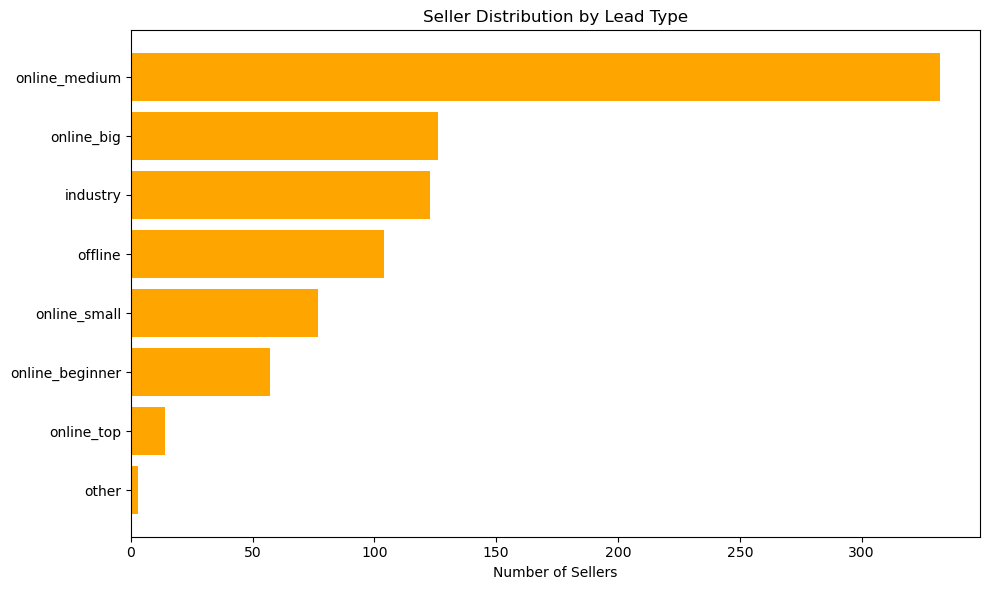

In [36]:
plt.figure(figsize=(10,6))
plt.barh(lead_type_perf.index, lead_type_perf["sellers"], color = 'orange')
plt.xlabel("Number of Sellers")
plt.title("Seller Distribution by Lead Type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Lead Type Insights
1. Most converted sellers come from a small number of lead types, meaning the platform attracts a clear seller persona rather than random businesses.
2. This suggests the marketing message resonates strongly with specific seller profiles.

3. The company should tailor acquisition campaigns to these high-representation lead types.

In [37]:
business_type_perf = (
    df[df["converted"] == True]
    .groupby("business_type")
    .agg(sellers=("seller_id","count"))
    .dropna()
    .sort_values("sellers", ascending=False)
)

business_type_perf

,sellers
business_type,
reseller,587
manufacturer,242
other,3


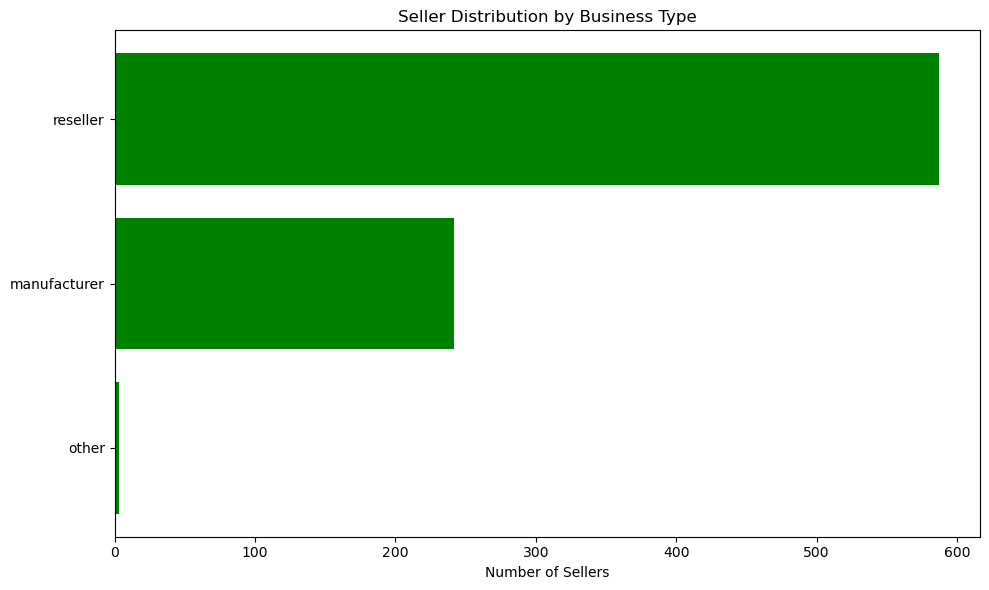

In [38]:
plt.figure(figsize=(10,6))
plt.barh(business_type_perf.index, business_type_perf["sellers"], color = "green")
plt.xlabel("Number of Sellers")
plt.title("Seller Distribution by Business Type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Type Insight
1. Converted sellers are concentrated in a couple dominant business types "Reseller" & "Manufacturer", with Reseller being the main contributer.


## Seller Targeting Recommendations

* **Refine** 

Use the dominant lead types and business types as the core targeting persona for future campaigns.

* **Align Marketing Messaging**

Ad copy, landing pages and onboarding content should speak directly to these seller profiles.

* **Improve Lead Qualification**

Since these attributes are known only after conversion, the company should collect this data earlier in the funnel to improve targeting and measurement.


## Executive Summary

## Project Goal

How can we improve the conversion rate of our leads?

This analysis explores how marketing channels, time trends, and seller characteristics influence lead conversion and seller acquisition.

# About The Dataset

Olist is the largest department store in Brazilian marketplaces, enabling small businesses to sell products via Olist stores.

* Two datasets were combined:

Marketing Leads dataset
Contains total leads, acquisition source and first contact date.
Closed Deals dataset
Contains converted leads (sellers), business segments and seller attributes.

* By joining these datasets we analyzed:

Marketing channel performance
Seller industry composition
Conversion trends over time
# KPI Overview
* Total Leads Generated **8,000**
* Total Sellers Acquired **842**
* Overall Conversion Rate **10.53%** 
* Leads Needed per Seller **9.5** 


## Marketing Effectiveness — Key Findings

* Organic Search & Paid Search = main growth engines
* Highest volume + strong conversion performance.
* Unknown channel has the highest conversion rate
* Indicates a tracking/attribution gap.
* Direct Traffic & Referral = high intent channels
* Convert well but bring lower volume.
* Social, Email & Display underperform
* Good exposure but weaker conversion efficiency.

## Time Trend Analysis — Key Findings
* January 2018 was a turning point
* Leads, conversions and conversion rate increased significantly.
* All channels grew simultaneously
* Suggests improved marketing strategy or brand awareness.
* December shows seasonal dip
* Likely holiday season effect.


## Business Segment Insights

* Core seller industries:

Home Decor
Health & Beauty
Household & Tools
Car Accessories

* Growth vertical:

Electronics & Computers

* Emerging niches:

Pet
Food & Supplements

## Seller Profile Insights

Seller attributes are collected mostly after conversion
→ reveals a data collection gap.

Converted sellers share common characteristics
→ a clear Ideal Seller Profile (ICP) exists.
 
## Strategic Recommendations

* Scale what works

Organic Search
Paid Search
High-performing channels

* Grow high-intent acquisition

Direct Traffic
Referral

* Optimize weaker channels

Social
Email
Display

* Double down on core seller industries

Home, Beauty, Household, Tools

* Expand high-value verticals

Electronics & Technology sellers

* Improve data collection

Capture seller attributes earlier in the funnel.